# Notebook 1 — One channel

*SWC ENC 2026 · ephys-one module*

Before we can count channels we need to understand what *one* of them does. The
answer is simple and strange: an ion channel is a **random switch**. It sits closed,
then at some unpredictable moment pops open and passes a fixed current, then at
another unpredictable moment snaps shut. All the statistics we use later come from
this picture, so we build it carefully here.

**In this notebook you will:**
1. Simulate a single channel as a **coin flip at every time step** and see what its
   current looks like.
2. Measure its **open probability** and see how it depends on voltage.
3. Measure how long it stays open or closed (**dwell times**) and see that they are
   exponentially distributed.
4. Watch what happens when many repeats of a voltage step are averaged — a
   preview of Notebook 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picopatch as pp

## 1. A channel is a switch with two rates

The simplest **kinetic scheme** has two states, **C**losed and **O**pen, and two
numbers:

- $\alpha$, the **opening rate**: the probability *per second* that a closed channel
  opens;
- $\beta$, the **closing rate**: the probability per second that an open channel closes.

Rates have units of 1/s. $\alpha = 150/\mathrm{s}$ means that, in a tiny interval
$\Delta t$, a closed channel opens with probability $\alpha\,\Delta t$ — e.g. with
$\Delta t = 20\ \mu s$ that's $150 \times 0.00002 = 0.003$, a 0.3% chance per tick.
Nothing about the channel's history matters: it has no memory, just two coins.

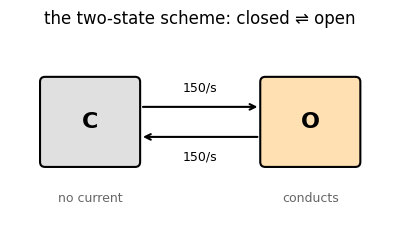

In [2]:
fig, ax = plt.subplots(figsize=(6, 2.6))
pp.plotting.plot_scheme(ax, pp.two_state_fixed(alpha=150, beta=150),
                        V=0, title="the two-state scheme: closed ⇌ open")
plt.show()

**Exercise 1** *(~8 min)*. Complete `simulate_channel`. Walk through time in steps of
`dt`; at each step, if the channel is closed, open it with probability `alpha*dt`; if
open, close it with probability `beta*dt`. Record the state (0 = closed, 1 = open)
at every step. `rng.random()` gives a uniform number in [0, 1), so "with probability
q" is `rng.random() < q`.

> **Check / unstuck.** With α = β = 150/s the channel should spend about half its
> time open and flip every few milliseconds. Stuck? `pp.simulate_two_state(alpha,
> beta, dt, n_steps, rng)` does exactly this.

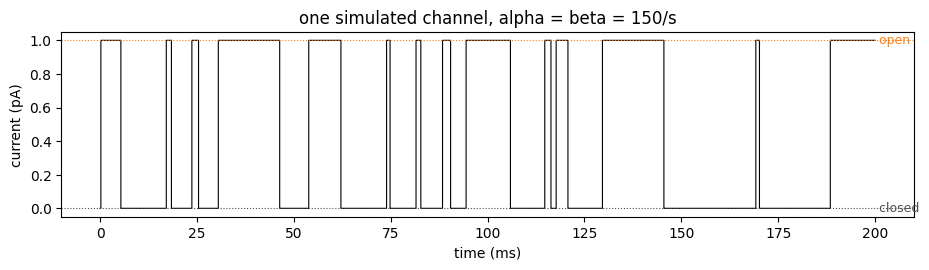

fraction of time open: 0.41


In [3]:
def simulate_channel(alpha, beta, dt, n_steps, rng):
    state = np.zeros(n_steps, dtype=int)      # 0 = closed, 1 = open
    s = 0
    for k in range(n_steps):
        if s == 0 and rng.random() < alpha * dt:
            s = 1
        elif s == 1 and rng.random() < beta * dt:
            s = 0
        state[k] = s
    return state

dt = 1 / pp.FS                                # 20 microseconds
n_steps = int(0.2 / dt)                       # 200 ms
rng = np.random.default_rng(0)
state = simulate_channel(alpha=150, beta=150, dt=dt, n_steps=n_steps, rng=rng)
i_unit = 1.0                                  # pA through the open channel
current = i_unit * state
t_ms = np.arange(n_steps) * dt * 1e3

pp.plotting.plot_single_channel(t_ms, current, i=i_unit,
                                title="one simulated channel, alpha = beta = 150/s")
plt.show()
print(f"fraction of time open: {state.mean():.2f}")

That square, hopping trace is what a real single-channel recording looks like (apart
from the noise). The channel is either passing `i` or passing nothing; there is no
in-between. Change the rates and the look changes: a large $\alpha$ means short
closed times, a large $\beta$ means short open times.

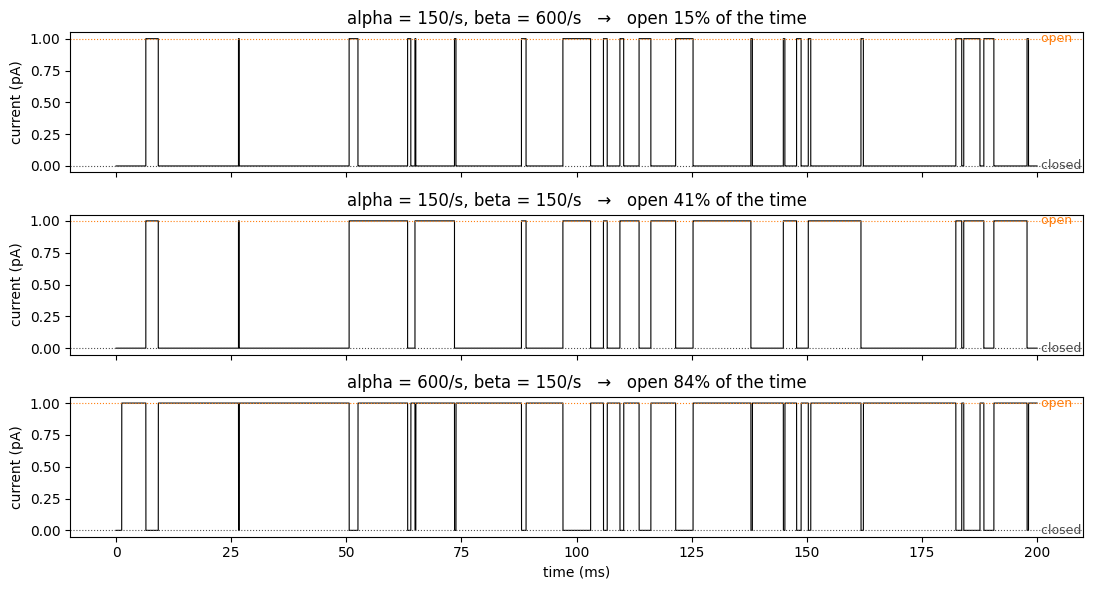

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, (a, b) in zip(axes, [(150, 600), (150, 150), (600, 150)]):
    st = pp.simulate_two_state(a, b, dt, n_steps, rng=1)
    pp.plotting.plot_single_channel(t_ms, i_unit * st, ax=ax, i=i_unit,
                                    title=f"alpha = {a}/s, beta = {b}/s   →   open {st.mean():.0%} of the time")
for ax in axes[:-1]:
    ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 2. Open probability

The **open probability** $p$ is the fraction of time the channel spends open. From
the traces above you can guess the rule: the channel is open more when it opens
faster ($\alpha$ big) or closes slower ($\beta$ small). The exact result is

$$p = \frac{\alpha}{\alpha + \beta}.$$

So with $\alpha = \beta$, $p = 0.5$; with $\alpha = 600, \beta = 150$, $p = 0.8$.

<details>
<summary><b>▸ Go deeper: where α/(α+β) comes from (optional)</b></summary>

Let $p(t)$ be the probability the channel is open at time $t$. In a small interval
$\Delta t$ it gains probability from closed channels opening, $\alpha \Delta t\,(1-p)$,
and loses probability from open channels closing, $\beta \Delta t\, p$. So

$$\frac{dp}{dt} = \alpha (1 - p) - \beta p .$$

At steady state $dp/dt = 0$, giving $\alpha(1-p) = \beta p$, i.e.
$p_\infty = \alpha / (\alpha + \beta)$. Away from steady state the solution is

$$p(t) = p_\infty + (p_0 - p_\infty)\, e^{-t/\tau}, \qquad \tau = \frac{1}{\alpha + \beta},$$

an exponential relaxation with time constant $\tau$. We'll see this curve in
section 4, when we average many sweeps.
</details>

### Voltage dependence

Voltage-gated channels have rates that depend on the membrane potential $V$. We use
the dependence from the paper:

$$\alpha(V) = \alpha_0\, e^{+2(V - 45)/25}, \qquad \beta(V) = \alpha_0\, e^{-2(V - 45)/25},$$

with $V$ in mV and $\alpha_0 = 150/\mathrm{s}$. Depolarising (making $V$ more positive)
speeds up opening and slows down closing, so $p$ rises with $V$. At $V = 45$ mV the
two rates are equal and $p = 0.5$. Here are the two rates, and the open probability
they imply, as functions of voltage:

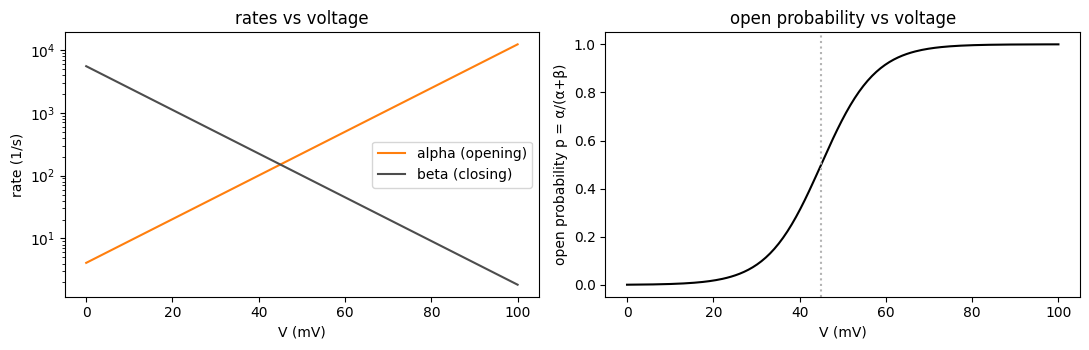

In [5]:
V = np.linspace(0, 100, 200)
scheme = pp.two_state()                       # the voltage-dependent two-state channel
p_inf = np.array([scheme.open_probability(v) for v in V])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].semilogy(V, pp.alpha_rate(V), label="alpha (opening)", color="tab:orange")
axes[0].semilogy(V, pp.beta_rate(V), label="beta (closing)", color="0.3")
axes[0].set_xlabel("V (mV)"); axes[0].set_ylabel("rate (1/s)"); axes[0].legend()
axes[0].set_title("rates vs voltage")
axes[1].plot(V, p_inf, color="k"); axes[1].axvline(45, color="0.7", ls=":")
axes[1].set_xlabel("V (mV)"); axes[1].set_ylabel("open probability p = α/(α+β)")
axes[1].set_title("open probability vs voltage")
plt.tight_layout(); plt.show()

**Exercise 2** *(~6 min)*. Simulate one channel held at each of 25, 45 and 65 mV for
2 s, measure the fraction of time it is open, and compare to $\alpha/(\alpha+\beta)$.
Use `pp.alpha_rate(V)` and `pp.beta_rate(V)` for the rates at a voltage, and your
`simulate_channel` (or `pp.simulate_two_state`) for the trace.

> **Check / unstuck.** You should get roughly 0.04, 0.5 and 0.96. With only 2 s of
> data expect a little scatter. Stuck? `scheme.open_probability(V)` gives the theory
> value; `pp.simulate_single(scheme, pp.constant_protocol(V, 2000))` the trace.

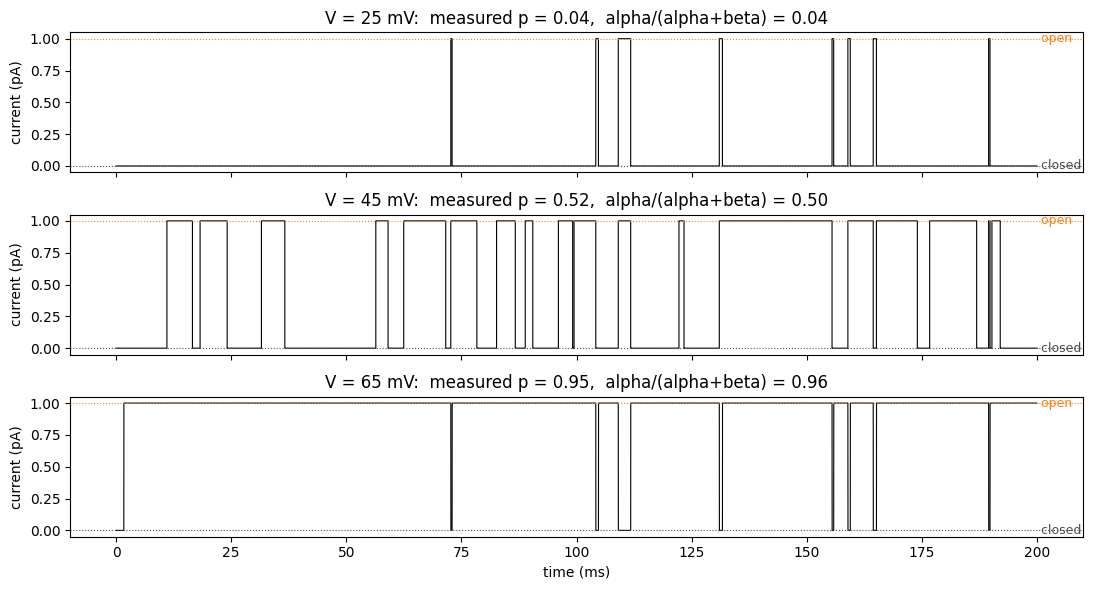

In [6]:
n_2s = int(2.0 / dt)
measured, theory = [], []
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, v in zip(axes, [25, 45, 65]):
    a, b = float(pp.alpha_rate(v)), float(pp.beta_rate(v))
    st = simulate_channel(a, b, dt, n_2s, np.random.default_rng(2))
    measured.append(st.mean()); theory.append(a / (a + b))
    tt = np.arange(n_2s) * dt * 1e3
    pp.plotting.plot_single_channel(tt[:10000], i_unit * st[:10000], ax=ax, i=i_unit,
                                    title=f"V = {v} mV:  measured p = {st.mean():.2f},  alpha/(alpha+beta) = {a/(a+b):.2f}")
for ax in axes[:-1]:
    ax.set_xlabel("")
plt.tight_layout(); plt.show()

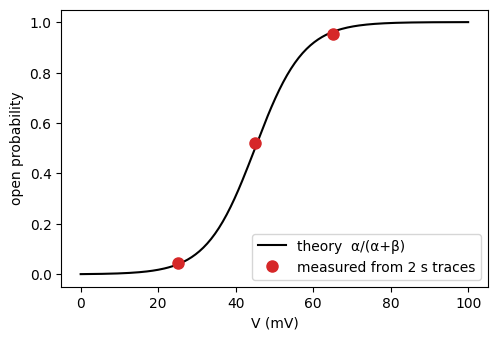

In [7]:
plt.figure(figsize=(5.5, 3.6))
plt.plot(V, p_inf, color="k", label="theory  α/(α+β)")
plt.plot([25, 45, 65], measured, "o", color="tab:red", ms=8, label="measured from 2 s traces")
plt.xlabel("V (mV)"); plt.ylabel("open probability"); plt.legend(); plt.show()

## 3. How long does it stay open? Dwell times

Look back at any trace: the open stretches have all sorts of lengths, some very
short, a few long. The duration of one stretch is a **dwell time**. Because the
channel has no memory — the chance of closing in the next tick is $\beta\,\Delta t$
no matter how long it has been open — short dwells are *always* more common than long
ones, and the histogram of dwell times is an **exponential** with mean $1/\beta$
(for open dwells) or $1/\alpha$ (for closed dwells).

This is the single-channel way of measuring the rates: the mean open time *is*
$1/\beta$.

<details>
<summary><b>▸ Go deeper: why dwell times are exponential (optional)</b></summary>

For a channel that is open now, the probability of *still* being open a time $t$
later is the probability of surviving $t/\Delta t$ ticks each with escape chance
$\beta\Delta t$:

$$S(t) = (1 - \beta\Delta t)^{t/\Delta t} \;\xrightarrow{\Delta t \to 0}\; e^{-\beta t}.$$

The density of dwell times is $-dS/dt = \beta e^{-\beta t}$: an exponential with mean
$1/\beta$. Same argument with $\alpha$ for closed dwells. If you histogram dwell
times on a log y-axis you get a straight line of slope $-\beta$.
</details>

**Exercise 3** *(~8 min)*. Complete `dwell_times`: given a 0/1 state array, return the
durations (in seconds) of every open stretch and every closed stretch. One approach:
find where the state changes (`np.diff(state) != 0`), and the gaps between successive
change points are the dwell lengths in samples; whether each stretch is open or closed
is given by the state at its start. Drop the first and last stretch (we didn't see
them begin or end).

> **Check / unstuck.** At 45 mV (α = β = 150/s) both mean dwell times should be
> about 1/150 s = 6.7 ms. Stuck? `pp.dwell_times(state, dt)`.

In [8]:
def dwell_times(state, dt):
    change = np.flatnonzero(np.diff(state) != 0) + 1    # indices where a new stretch starts
    starts, stops = change[:-1], change[1:]             # interior stretches only
    lengths = (stops - starts) * dt
    is_open = state[starts] == 1
    return lengths[is_open], lengths[~is_open]

a45, b45 = float(pp.alpha_rate(45)), float(pp.beta_rate(45))
n_10s = int(10.0 / dt)
st45 = pp.simulate_two_state(a45, b45, dt, n_10s, rng=3)   # 10 s of data for a smooth histogram
open_dw, closed_dw = dwell_times(st45, dt)
print(f"{len(open_dw)} open dwells, mean {open_dw.mean()*1e3:.2f} ms   (1/beta = {1e3/b45:.2f} ms)")
print(f"{len(closed_dw)} closed dwells, mean {closed_dw.mean()*1e3:.2f} ms (1/alpha = {1e3/a45:.2f} ms)")

755 open dwells, mean 6.84 ms   (1/beta = 6.67 ms)
754 closed dwells, mean 6.40 ms (1/alpha = 6.67 ms)


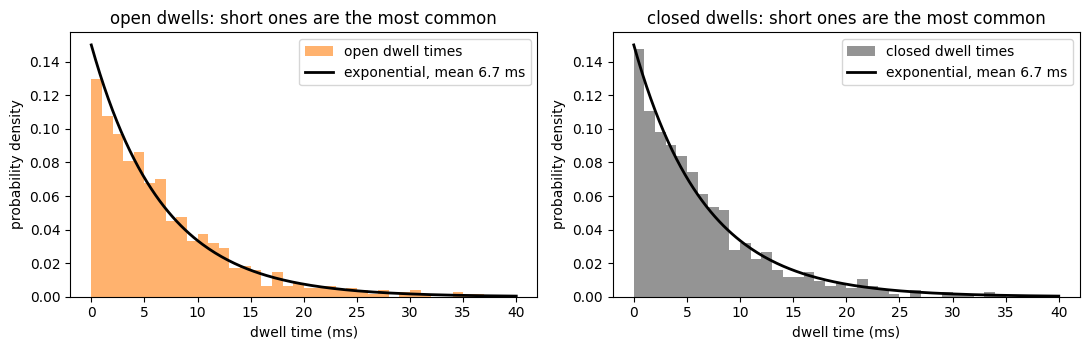

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, dw, rate, name, color in [(axes[0], open_dw, b45, "open", "tab:orange"),
                                  (axes[1], closed_dw, a45, "closed", "0.3")]:
    bins = np.linspace(0, 40, 41)
    ax.hist(dw * 1e3, bins=bins, density=True, color=color, alpha=0.6, label=f"{name} dwell times")
    tt = np.linspace(0, 40, 200)
    ax.plot(tt, rate * np.exp(-rate * tt / 1e3) / 1e3, color="k", lw=2,
            label=f"exponential, mean {1e3/rate:.1f} ms")
    ax.set_xlabel("dwell time (ms)"); ax.set_ylabel("probability density"); ax.legend()
    ax.set_title(f"{name} dwells: short ones are the most common")
plt.tight_layout(); plt.show()

## 4. A voltage step, repeated: the ensemble average

Now the experiment we'll use for the rest of the module. Hold the membrane at
−80 mV, where the channel is almost always closed, then **step** to +65 mV, where it
is open 96% of the time. The channel doesn't open instantly: it takes a random
*latency* to its first opening, then flickers as before. Each repeat of the step —
each **sweep** — looks different.

But average many sweeps and the randomness washes out, leaving a smooth curve: the
**open probability as a function of time**, $p(t)$, rising from ~0 to 0.96 with the
time constant $\tau = 1/(\alpha+\beta)$ at the new voltage. That smooth average is
exactly what a patch with many channels records all at once — the subject of
Notebook 2.

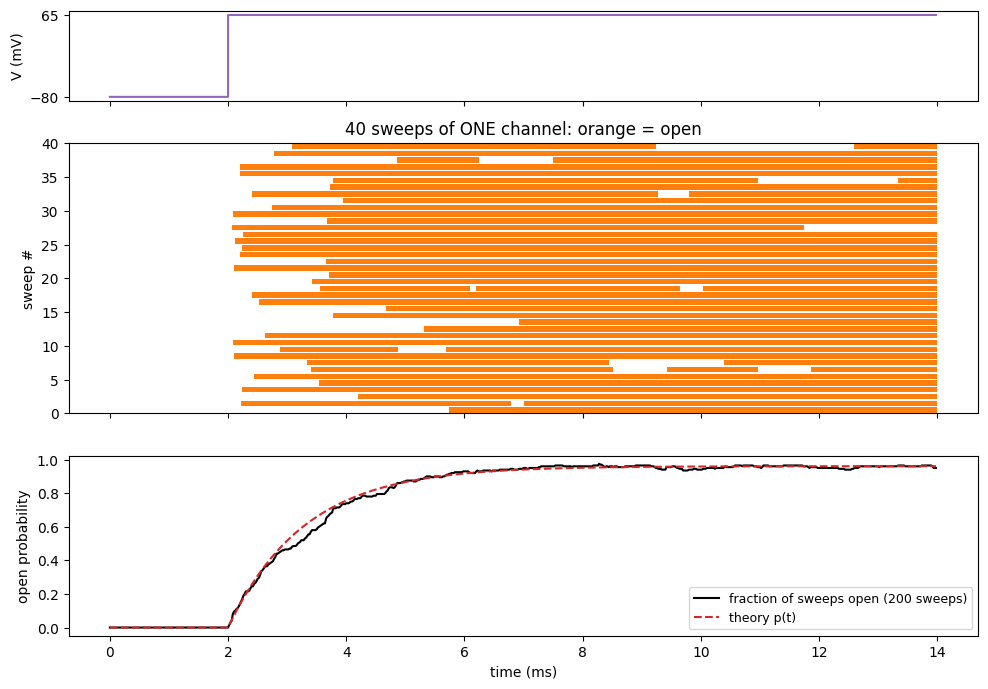

relaxation time constant at +65 mV: tau = 1/(alpha+beta) = 1.29 ms


In [10]:
protocol = pp.step_protocol(v_hold=-80, v_step=65, t_pre_ms=2, t_step_ms=12)
states = pp.simulate_single(scheme, protocol, n_sweeps=200, rng=4)    # (sweeps, samples)
open_1 = states == 1

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True,
                         gridspec_kw=dict(height_ratios=[1, 3, 2]))
pp.plotting.plot_voltage(axes[0], protocol.t_ms, protocol.V)
# raster: a bar wherever the channel is open, one row per sweep
pp.plotting.plot_open_raster(axes[1], open_1, protocol.t_ms, n_show=40,
                             title="40 sweeps of ONE channel: orange = open")
axes[2].plot(protocol.t_ms, open_1.mean(axis=0), color="k", lw=1.5, label="fraction of sweeps open (200 sweeps)")
axes[2].plot(protocol.t_ms, pp.exact_open_probability(scheme, protocol), color="tab:red", ls="--",
             label="theory p(t)")
axes[2].set_xlabel("time (ms)"); axes[2].set_ylabel("open probability"); axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()
tau_ms = 1e3 / (float(pp.alpha_rate(65)) + float(pp.beta_rate(65)))
print(f"relaxation time constant at +65 mV: tau = 1/(alpha+beta) = {tau_ms:.2f} ms")

**Where we are.** One channel: two rates, a memoryless random switch, open probability
$\alpha/(\alpha+\beta)$ that rises with voltage, exponential dwell times, and an
ensemble average that relaxes exponentially after a step. In Notebook 2 we put $N$ of
these switches in one patch and ask what their *sum* looks like — and, crucially, how
much it fluctuates.